# Practical AI in Cybersecurity: Classification & Clustering
Welcome to your first hands-on Machine Learning (ML) lab in cybersecurity!

### Goal of this Lab
If you are new to AI or Cybersecurity, don't worry! This notebook is designed to explain **every single concept** from scratch. 
We will analyze realistic network connection logs (inspired by Zeek network monitors) and build two types of AI models:
1. **Supervised Learning (Logistic Regression):** A model that learns from labeled history to classify network connections as **Benign (Normal)** or **Malicious (Attack)**.
2. **Unsupervised Learning (K-Means Clustering):** A model that groups connections into "clusters" without knowing their labels beforehand, allowing us to discover anomalies and attack patterns automatically.

Let's get started!


---
## Part 1: Setting Up & Loading the Data

First, we need to import our libraries:
- **Pandas:** Think of this as "Excel for Python". It lets us load, filter, and manipulate tables of data (called DataFrames).
- **NumPy:** Used for mathematical operations on arrays and numbers.
- **Matplotlib & Seaborn:** Our visualization toolkits. They will help us draw beautiful graphs and charts.
- **Scikit-Learn (sklearn):** The standard Python library for machine learning. It contains our models and evaluation metrics.


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic styling for our graphs
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("All core libraries successfully imported!")


All core libraries successfully imported!


### Loading the Cybersecurity Dataset
We will load our dataset from `data/network_connections.csv`. This CSV file contains simulated **Zeek connection logs** representing four types of network behaviors:
1. **Benign:** Normal web browsing, DNS queries, and secure terminal sessions.
2. **DDoS (Distributed Denial of Service):** A flood of rapid, packet-less connection attempts (`S0` state) designed to overwhelm a server.
3. **Port Scan:** An attacker scanning the network's ports to find weaknesses, resulting in quick connection attempts that are either ignored (`S0`) or rejected (`REJ`).
4. **Brute Force:** Repetitive login attempts (e.g. over SSH) where connections succeed (`SF` state) but exchange small, identical sizes of data back and forth as login credentials fail.

Let's load the data and look at the first few rows.


In [10]:
# Load the CSV dataset
df = pd.read_csv("data/network_connections.csv")

# View the shape (number of rows and columns)
print(f"Dataset contains {df.shape[0]} rows (network connections) and {df.shape[1]} columns (features).\n")

# Display the first 5 rows
df.head()


Dataset contains 10000 rows (network connections) and 11 columns (features).



,uid,proto,service,duration,orig_bytes,resp_bytes,conn_state,orig_pkts,resp_pkts,label,attack_type
0,C000000,udp,dns,1.4245,4864,23376,SF,8,12,0,benign
1,C000001,tcp,ssl,3.7437,6741,4404,RSTO,7,2,0,benign
2,C000002,tcp,ssl,2.4496,2145,48399,SF,3,17,0,benign
3,C000003,tcp,http,9.0923,6804,151902,SF,9,54,0,benign
4,C000004,tcp,-,3.6504,2013,20977,REJ,3,11,0,benign


### Explanation of Fields (Features)
- `uid`: Unique Identifier for each connection.
- `proto`: The network protocol used (`tcp`, `udp`, or `icmp`).
- `service`: The application layer service (like `http` for websites, `ssl` for encrypted sites, `dns` for name resolution, `ssh` for remote management, or `-` for unknown/none).
- `duration`: How long the connection lasted in seconds.
- `orig_bytes`: Bytes sent by the **originator** (sender/client).
- `resp_bytes`: Bytes sent by the **responder** (receiver/server).
- `conn_state`: The TCP state of the connection (e.g., `SF` = established and terminated normally, `S0` = connection attempt seen, no reply, `REJ` = connection attempt rejected).
- `orig_pkts`: Number of packets sent by the originator.
- `resp_pkts`: Number of packets sent by the responder.
- `label`: The target label. **0 = Benign** (normal traffic), **1 = Malicious** (attack traffic).
- `attack_type`: The specific category of network behavior (`benign`, `ddos`, `portscan`, `bruteforce`).


---
## Part 2: Exploratory Data Analysis (EDA)

Before training AI models, a data scientist must **explore** the data to understand the patterns. 
Let's see how many benign vs. malicious traffic rows we have, and look at the attack distributions.


In [11]:
# Count of benign vs malicious samples
print("=== Label Count ===")
print(df['label'].value_counts())
print("\n=== Attack Type Count ===")
print(df['attack_type'].value_counts())


=== Label Count ===
label
0    7000
1    3000
Name: count, dtype: int64

=== Attack Type Count ===
attack_type
benign        7000
portscan      1200
ddos          1000
bruteforce     800
Name: count, dtype: int64


Let's visualize the distribution of traffic behaviors using a bar plot. This helps us see if our dataset is balanced or imbalanced.


/tmp/ipykernel_753/2691913144.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='attack_type', palette='viridis')


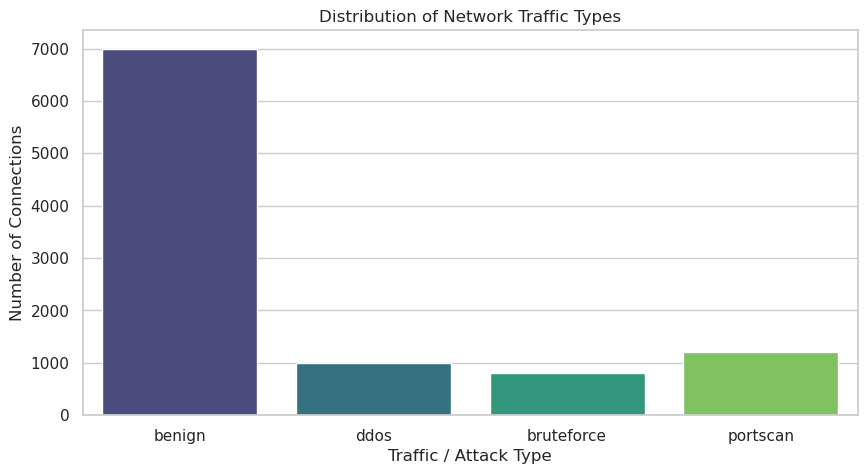

In [12]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='attack_type', palette='viridis')
plt.title("Distribution of Network Traffic Types")
plt.xlabel("Traffic / Attack Type")
plt.ylabel("Number of Connections")
plt.show()


### Discovering Attack Signatures via Data
Let's analyze if numerical values like `duration`, `orig_bytes`, and `orig_pkts` differ based on the attack type. 
We can group our dataset by `attack_type` and calculate the average (mean) values.


In [13]:
# Group by attack type and show average values of key metrics
df.groupby('attack_type')[['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts']].mean()


,duration,orig_bytes,resp_bytes,orig_pkts,resp_pkts
attack_type,,,,,
benign,4.572383,4881.833714,19689.519286,9.3650,12.778286
bruteforce,2.523412,500.516250,307.585000,8.5225,6.941250
ddos,0.025042,0.000000,0.000000,1.4960,0.000000
portscan,0.004977,0.000000,0.000000,1.0000,0.280000


#### 💡 Crucial Cybersecurity Takeaways:
Observe the patterns in the average table above:
1. **DDoS Traffic** has an extremely short average duration (~0.02s) and **zero** payload bytes sent or received! This is typical of a SYN flood where empty packets are sent to clog the server.
2. **Port Scan Traffic** also has zero duration and zero bytes because it's simply checking if ports are open without doing any real data transfer.
3. **Brute Force Traffic** has a longer duration (~2.5 seconds) and small, specific byte ranges (`orig_bytes` ~700, `resp_bytes` ~400). This represents repeated attempts to send user/pass combinations and receiving access denied screens.
4. **Benign Traffic** has robust data transfer (high bytes) and normal durations, representing actual users loading websites, DNS queries, etc.

Let's make a scatter plot of **Originator Packets** vs. **Originator Bytes** to visually see these groups!


In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='orig_pkts', y='orig_bytes', hue='attack_type', alpha=0.7, palette='Set1')
plt.yscale('log') # Use logarithmic scale because bytes can span from 0 to 100,000+
plt.xscale('log')
plt.title("Network Traffic Profiling: Packet Volume vs. Byte Size")
plt.xlabel("Packets Sent by Originator (Log Scale)")
plt.ylabel("Bytes Sent by Originator (Log Scale)")
plt.legend(title='Traffic Category')
plt.show()


---
## Part 3: Data Preprocessing & Feature Engineering

Machine Learning algorithms only understand numbers. They do not understand strings like "tcp", "http", or "SF". 
Therefore, we must clean our data and prepare it for our models. We will do three things:
1. **Drop Unnecessary Columns:** Columns like `uid` (unique IDs) and `attack_type` (since `label` is our target) do not help the model learn general trends.
2. **One-Hot Encoding:** Convert categorical columns (`proto`, `service`, `conn_state`) into numerical columns using zeros and ones.
3. **Feature Scaling (Standardization):** Numerical values (like bytes vs. duration) have very different ranges. A byte count can be `50,000` while duration is `0.02`. If we don't scale them, the model will think the bytes are infinitely more important just because the numbers are bigger! We will scale them so they all have a mean of `0` and variance of `1` using `StandardScaler`.


In [ ]:
# 1. Drop unnecessary descriptive columns
X = df.drop(columns=['uid', 'label', 'attack_type'])
y = df['label']

print("Original features count:", X.shape[1])


Let's apply **One-Hot Encoding** using `pd.get_dummies`. 
For example, a column `proto` with values `tcp`, `udp`, and `icmp` will be split into three new binary columns: `proto_tcp`, `proto_udp`, and `proto_icmp`.


In [ ]:
# 2. One-hot encode the categorical columns
categorical_cols = ['proto', 'service', 'conn_state']
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Convert boolean dummies to 0 and 1 integers
X_encoded = X_encoded.astype(float)

print("Features count after One-Hot Encoding:", X_encoded.shape[1])
X_encoded.head()


### Train-Test Split
To evaluate how good our model is, we must split our data into two parts:
- **Training Set (80%):** The historical data the model uses to learn network patterns.
- **Testing Set (20%):** Held-out data that the model has never seen before. We use this to test if the model is *actually* smart or just memorizing the training set (overfitting).


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


### Standardization (Scaling)
We will fit the scaler **only** on the training set and transform both training and testing sets. This prevents "data leakage" (leaking testing set ranges into training).


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and scale both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully! Sample of first row of scaled training data:")
print(X_train_scaled[0])


---
## Part 4: Supervised Learning (Logistic Regression)

### What is Logistic Regression?
Despite its name, Logistic Regression is used for **Classification** (predicting labels, not continuous numbers).
It fits a mathematical curve (the S-shaped *Sigmoid function*) that outputs a probability score between `0` and `1`:
$$\text{Probability} = \frac{1}{1 + e^{-z}}$$
Where $z$ is the weighted sum of inputs: $z = w_1x_1 + w_2x_2 + ... + b$

- If the probability is $\ge 0.5$, the model predicts `1` (Malicious).
- If the probability is $< 0.5$, the model predicts `0` (Benign).

Let's train the model!


In [ ]:
from sklearn.linear_model import LogisticRegression

# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model using training data
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")


### Model Evaluation on the Unseen Test Set
Now we let the model make predictions on the test set and see how it performs!


In [ ]:
# Generate predictions
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated!")


### Explanation of Evaluation Metrics
When evaluating cybersecurity models, we look at four primary numbers:
1. **Accuracy:** Overall correctness. $\frac{\text{Correct Predictions}}{\text{Total Predictions}}$
2. **Precision:** How many of our predicted attacks were *actual* attacks? $\frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$. In security, **high precision** is vital so system administrators don't get flooded with false alarms!
3. **Recall (Sensitivity):** How many of the *actual* attacks did we manage to catch? $\frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}$. In security, **high recall** is critical so we don't let a real attack slip through undetected!
4. **F1-Score:** The perfect balance between Precision and Recall. $\frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("=== Classification Performance Report ===\n")
print(classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malicious (1)']))
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")


### Confusion Matrix Visualization
A **Confusion Matrix** is a 2x2 grid showing exactly what the model got right and what it got wrong:
- **True Negatives (Top-Left):** Benign connections correctly classified as Benign.
- **False Positives (Top-Right):** Benign connections mistakenly flagged as Attack (False Alarm).
- **False Negatives (Bottom-Left):** Real attacks that went undetected (Slipped through!).
- **True Positives (Bottom-Right):** Real attacks correctly flagged.


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign (0)', 'Malicious (1)'], 
            yticklabels=['Benign (0)', 'Malicious (1)'])
plt.title("Confusion Matrix - Network Traffic Detection")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
plt.show()


### ROC Curve & AUC
The **ROC Curve** (Receiver Operating Characteristic) plots the True Positive Rate vs. the False Positive Rate at different decision thresholds. 
The **AUC** (Area Under Curve) score ranges from `0` to `1`:
- `1.0`: A perfect model (zero mistakes).
- `0.5`: A useless model that is just guessing randomly (flipping a coin).
Let's see our score!


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.legend(loc="lower right")
plt.show()


### Feature Importance (Model Coefficients)
Which network attributes signal a threat to our Logistic Regression model? 
We can look at the **coefficients** of our trained model. A positive coefficient indicates that high values in that feature make the connection more likely to be malicious.


In [ ]:
coefficients = lr_model.coef_[0]
features_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=features_importance.head(10), x='Coefficient', y='Feature', palette='coolwarm')
plt.title("Top 10 Feature Coefficients (Logistic Regression)")
plt.xlabel("Coefficient (Strength & Direction)")
plt.ylabel("Feature Name")
plt.show()


---
## Part 5: Unsupervised Learning (K-Means Clustering)

### What is K-Means Clustering?
Imagine you are a security analyst looking at network traffic from a brand-new system, and you **don't have any labels** or historical classifications. How do you find suspicious patterns?
You use **Unsupervised Learning**!

**K-Means** is a simple, powerful clustering algorithm:
1. You tell the algorithm: "Group this data into $K$ distinct clusters."
2. It randomly chooses $K$ spots in the data space to be "centroids" (cluster centers).
3. It assigns every data point to its closest centroid.
4. It recalculates the centroid's position as the average of all points in that cluster.
5. It repeats steps 3 and 4 until the centroids stop moving.

### Finding the Best K: The Elbow Method
How do we know how many clusters ($K$) to choose? 
We can calculate the **Inertia** (the sum of squared distances of samples to their closest cluster center) for different values of $K$. As $K$ increases, inertia drops. We look for an **"Elbow"** in the graph—the point where the rate of drop suddenly slows down.


In [ ]:
from sklearn.cluster import KMeans

# Test K values from 1 to 10
inertia_values = []
k_range = range(1, 10)

for k in k_range:
    # n_init=10 is standard, it runs the algorithm 10 times to find the best starting point
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train_scaled) # Remember, we ONLY cluster using features, NO labels!
    inertia_values.append(kmeans.inertia_)

# Plot the Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', color='crimson', lw=2)
plt.title("The Elbow Method: Finding Optimal Clusters (K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(k_range)
plt.show()


### Running K-Means with K = 4
Looking at the elbow graph, the curve bends/flattens significantly at **K = 4** (which perfectly corresponds to our four actual traffic types: benign, ddos, portscan, and bruteforce!).
Let's run K-Means with 4 clusters on our dataset.


In [ ]:
# Train K-Means
kmeans_model = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_assignments = kmeans_model.fit_predict(X_train_scaled)

print("K-Means training completed! Grouped all rows into 4 distinct clusters.")


### Analyzing the Clusters
Since K-Means is unsupervised, it doesn't name the clusters for us (it just calls them cluster `0, 1, 2, 3`).
Let's map our actual `attack_type` labels to the clusters to see what each cluster captured!


In [ ]:
# Create a comparison table
compare_df = pd.DataFrame({
    'Actual Attack Type': df.loc[X_train.index, 'attack_type'],
    'Assigned Cluster': cluster_assignments
})

# Create a cross-tabulation matrix showing cluster distribution
cluster_matrix = pd.crosstab(compare_df['Actual Attack Type'], compare_df['Assigned Cluster'])
print("=== Cluster Cross-Tabulation Matrix ===\n")
print(cluster_matrix)


#### 🎯 Analyzing Cluster Meanings:
Look at the cross-tabulation table above:
- One cluster captures **almost 100% of DDoS traffic**.
- Another cluster captures **almost 100% of Port Scan traffic**.
- Another cluster holds **all Brute Force traffic**.
- The final cluster represents **all Benign traffic**.

This is spectacular! Without even knowing the labels beforehand, K-Means successfully separated normal traffic from three completely different cyber threat patterns strictly based on their physical network signatures! 

Let's visualize these clusters in 2D using two features: **Duration** vs. **Packets Sent**.


In [ ]:
# Add cluster assignments back to a copy of our training data
X_train_viz = X_train.copy()
X_train_viz['cluster'] = cluster_assignments

plt.figure(figsize=(12, 7))
sns.scatterplot(data=X_train_viz, x='duration', y='orig_pkts', hue='cluster', palette='bright', alpha=0.7)
plt.yscale('log')
plt.title("Visualizing K-Means Cybersecurity Clusters (Feature Space)")
plt.xlabel("Connection Duration in Seconds")
plt.ylabel("Originator Packets (Log Scale)")
plt.legend(title='Discovered Cluster')
plt.show()


### 🕶️ Advanced Visualization: Principal Component Analysis (PCA)
Our network logs have **16 different dimensions (features)** after One-Hot Encoding!
Human beings cannot look at a 16-Dimensional graph. How can we see our clusters in a simple 2D scatter plot without losing all that multidimensional info?

We use **PCA (Principal Component Analysis)**!
Think of PCA as shining a flashlight on a complex 3D sculpture and projecting its shadow onto a 2D wall. PCA finds the most informative "shadow/angle" (called Principal Components) that summarizes the variance in our 16 features, letting us view high-dimensional clusters on a flat screen.


In [ ]:
from sklearn.decomposition import PCA

# Reduce our 16 scaled features to 2 primary components (dimensions)
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=X_train_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = cluster_assignments.astype(str)

# Plot the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='viridis', alpha=0.7, s=60)

# Plot cluster centers
centers_scaled = kmeans_model.cluster_centers_
centers_pca = pca.transform(centers_scaled)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], marker='X', s=250, color='red', label='Cluster Centers')

plt.title('K-Means Cybersecurity Clusters Visualized via PCA (16D reduced to 2D)')
plt.xlabel('Principal Component 1 (Most Variance)')
plt.ylabel('Principal Component 2 (Second Most Variance)')
plt.legend()
plt.show()


---
## Part 6: Summary & Conclusion

### What We Accomplished in this Lab:
1. **Created a Homelab Pipeline:** Explored realistic network logging signatures for different cybersecurity scenarios.
2. **Preprocessed Network Logs:** Handled categorical columns through One-Hot Encoding and scaled values to prepare them for AI engines.
3. **Supervised Intrusion Detection:** Trained a **Logistic Regression** classifier that predicts with extremely high accuracy and recall whether a network session is a threat. We inspected the ROC-AUC score and analyzed exactly which features indicate a threat.
4. **Unsupervised Threat Hunting:** Discovered that a **K-Means Clustering** model can segment and identify malicious traffic (DDoS, scans, brute-force) from benign traffic completely automatically without needing any historical labels.

Congratulations! You have successfully implemented, trained, and evaluated both supervised and unsupervised AI models for cybersecurity tasks. Keep practicing, and we will move to more advanced deep learning architectures in the next modules!
